In [8]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import joblib

In [9]:
DATA_PATH = "./condition+monitoring+of+hydraulic+systems"

In [10]:
sensor_files = [

    "PS1",
    "PS2",
    "PS3",
    "PS4",
    "PS5",
    "PS6",

    "EPS1",

    "FS1",
    "FS2",

    "TS1",
    "TS2",
    "TS3",
    "TS4",

    "VS1"

]

In [11]:


def extract_features(data, sensor_name):

    features = pd.DataFrame()

    # Mean
    features[sensor_name + "_mean"] = data.mean(axis=1)

    # Standard deviation
    features[sensor_name + "_std"] = data.std(axis=1)

    # Minimum value
    features[sensor_name + "_min"] = data.min(axis=1)

    # Maximum value
    features[sensor_name + "_max"] = data.max(axis=1)

    # Median
    features[sensor_name + "_median"] = data.median(axis=1)

    # Range
    features[sensor_name + "_range"] = (
        data.max(axis=1) - data.min(axis=1)
    )

    # Root Mean Square
    features[sensor_name + "_rms"] = np.sqrt(
        (data ** 2).mean(axis=1)
    )

    return features

In [12]:
all_features = []

for sensor in sensor_files:

    print(f"Processing {sensor}...")

    file_path = os.path.join(
        DATA_PATH,
        sensor + ".txt"
    )

    # Load sensor data
    sensor_data = pd.read_csv(

        file_path,

        sep=r"\s+",

        header=None

    )

    print(
        f"{sensor} shape:",
        sensor_data.shape
    )

    # Extract statistical features
    sensor_features = extract_features(

        sensor_data,

        sensor

    )

    all_features.append(sensor_features)


print("\nAll sensor files processed successfully.")


Processing PS1...
PS1 shape: (2205, 6000)
Processing PS2...
PS2 shape: (2205, 6000)
Processing PS3...
PS3 shape: (2205, 6000)
Processing PS4...
PS4 shape: (2205, 6000)
Processing PS5...
PS5 shape: (2205, 6000)
Processing PS6...
PS6 shape: (2205, 6000)
Processing EPS1...
EPS1 shape: (2205, 6000)
Processing FS1...
FS1 shape: (2205, 600)
Processing FS2...
FS2 shape: (2205, 600)
Processing TS1...
TS1 shape: (2205, 60)
Processing TS2...
TS2 shape: (2205, 60)
Processing TS3...
TS3 shape: (2205, 60)
Processing TS4...
TS4 shape: (2205, 60)
Processing VS1...
VS1 shape: (2205, 60)

All sensor files processed successfully.


In [13]:
X = pd.concat(

    all_features,

    axis=1

)


print("\nFinal Feature Dataset Shape:")

print(X.shape)


print("\nFirst 5 Rows:")

print(X.head())



Final Feature Dataset Shape:
(2205, 98)

First 5 Rows:
     PS1_mean    PS1_std  PS1_min  PS1_max  PS1_median  PS1_range     PS1_rms  \
0  160.673492  13.939309   145.83   191.51      156.25      45.68  161.276914   
1  160.603320  14.118967   145.73   191.47      156.06      45.74  161.222636   
2  160.347720  14.192619   145.37   191.41      155.72      46.04  160.974495   
3  160.188088  14.227803   145.14   191.34      155.56      46.20  160.818594   
4  160.000472  14.276434   144.95   191.41      155.34      46.46  160.636028   

     PS2_mean    PS2_std  PS2_min  ...  TS4_median  TS4_range    TS4_rms  \
0  109.466914  47.114508      0.0  ...      31.576      3.231  31.764550   
1  109.354890  47.045611      0.0  ...      34.553      1.500  34.496568   
2  109.158845  46.992060      0.0  ...      35.635      1.043  35.647341   
3  109.064807  46.972221      0.0  ...      36.635      0.883  36.580392   
4  108.931434  46.874946      0.0  ...      37.439      0.789  37.428654   



In [14]:
profile_path = os.path.join(

    DATA_PATH,

    "profile.txt"

)


profile = pd.read_csv(

    profile_path,

    sep=r"\s+",

    header=None

)


profile.columns = [

    "cooler_condition",

    "valve_condition",

    "pump_leakage",

    "accumulator_pressure",

    "stable_flag"

]


print(profile.head())


print("\nProfile Shape:")

print(profile.shape)


   cooler_condition  valve_condition  pump_leakage  accumulator_pressure  \
0                 3              100             0                   130   
1                 3              100             0                   130   
2                 3              100             0                   130   
3                 3              100             0                   130   
4                 3              100             0                   130   

   stable_flag  
0            1  
1            1  
2            1  
3            1  
4            1  

Profile Shape:
(2205, 5)


In [15]:
# ============================================================
# 8. SELECT TARGET
# ============================================================

y = profile["pump_leakage"]


print("\nPump Leakage Class Distribution:")

print(y.value_counts())


print("\nPercentage Distribution:")

print(
    y.value_counts(normalize=True) * 100
)



Pump Leakage Class Distribution:
pump_leakage
0    1221
2     492
1     492
Name: count, dtype: int64

Percentage Distribution:
pump_leakage
0    55.374150
2    22.312925
1    22.312925
Name: proportion, dtype: float64


In [16]:
# ============================================================
# 9. FINAL DATASET CHECK
# ============================================================

print("Feature Dataset Shape:", X.shape)

print("Target Dataset Shape:", y.shape)


print("\nMissing Values:")

print(X.isnull().sum().sum())


print("\nTarget Classes:")

print(y.unique())

Feature Dataset Shape: (2205, 98)
Target Dataset Shape: (2205,)

Missing Values:
0

Target Classes:
[0 2 1]


In [17]:
# ============================================================
# 10. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


print("Training Samples:", X_train.shape[0])

print("Testing Samples:", X_test.shape[0])

Training Samples: 1764
Testing Samples: 441


In [29]:
# ============================================================
# 11. DEFINE MODELS
# ============================================================

models = {

    "Logistic Regression":

        Pipeline([

            ("scaler", StandardScaler()),

            ("model",

             LogisticRegression(

                 max_iter=5000,

                 random_state=42

             ))

        ]),


    "K-Nearest Neighbors":

        Pipeline([

            ("scaler", StandardScaler()),

            ("model",

             KNeighborsClassifier(

                 n_neighbors=5

             ))

        ]),


    "Support Vector Machine":

        Pipeline([

            ("scaler", StandardScaler()),

            ("model",

             SVC(

                #  probability=True,

                 random_state=42

             ))

        ]),


    "Random Forest":

        RandomForestClassifier(

            n_estimators=300,

            random_state=42,

            class_weight="balanced"

        ),


    "Extra Trees":

        ExtraTreesClassifier(

            n_estimators=300,

            random_state=42,

            class_weight="balanced"

        ),


    "Gradient Boosting":

        GradientBoostingClassifier(

            random_state=42

        )

}

In [30]:
# ============================================================
# 12. TRAIN AND EVALUATE MODELS
# ============================================================

results = []

trained_models = {}


for name, model in models.items():

    print("\n")

    print("=" * 60)

    print(f"TRAINING: {name}")

    print("=" * 60)


    # Train model
    model.fit(

        X_train,

        y_train

    )


    # Save trained model temporarily
    trained_models[name] = model


    # Prediction
    y_pred = model.predict(

        X_test

    )


    # Calculate metrics

    accuracy = accuracy_score(

        y_test,

        y_pred

    )


    precision = precision_score(

        y_test,

        y_pred,

        average="weighted",

        zero_division=0

    )


    recall = recall_score(

        y_test,

        y_pred,

        average="weighted",

        zero_division=0

    )


    f1 = f1_score(

        y_test,

        y_pred,

        average="weighted",

        zero_division=0

    )


    print("\nAccuracy:")

    print(round(accuracy, 4))


    print("\nPrecision:")

    print(round(precision, 4))


    print("\nRecall:")

    print(round(recall, 4))


    print("\nF1 Score:")

    print(round(f1, 4))


    # Store results

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1

    })




TRAINING: Logistic Regression

Accuracy:
0.9977

Precision:
0.9978

Recall:
0.9977

F1 Score:
0.9977


TRAINING: K-Nearest Neighbors

Accuracy:
0.9297

Precision:
0.9297

Recall:
0.9297

F1 Score:
0.9297


TRAINING: Support Vector Machine

Accuracy:
0.9864

Precision:
0.9865

Recall:
0.9864

F1 Score:
0.9864


TRAINING: Random Forest

Accuracy:
1.0

Precision:
1.0

Recall:
1.0

F1 Score:
1.0


TRAINING: Extra Trees

Accuracy:
1.0

Precision:
1.0

Recall:
1.0

F1 Score:
1.0


TRAINING: Gradient Boosting

Accuracy:
0.9977

Precision:
0.9978

Recall:
0.9977

F1 Score:
0.9977


In [31]:
# ============================================================
# 13. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(

    results

)


results_df = results_df.sort_values(

    by="F1 Score",

    ascending=False

)


print("\n")

print("=" * 70)

print("MODEL COMPARISON RESULTS")

print("=" * 70)


print(

    results_df.round(4)

)



MODEL COMPARISON RESULTS
                    Model  Accuracy  Precision  Recall  F1 Score
4             Extra Trees    1.0000     1.0000  1.0000    1.0000
3           Random Forest    1.0000     1.0000  1.0000    1.0000
5       Gradient Boosting    0.9977     0.9978  0.9977    0.9977
0     Logistic Regression    0.9977     0.9978  0.9977    0.9977
2  Support Vector Machine    0.9864     0.9865  0.9864    0.9864
1     K-Nearest Neighbors    0.9297     0.9297  0.9297    0.9297


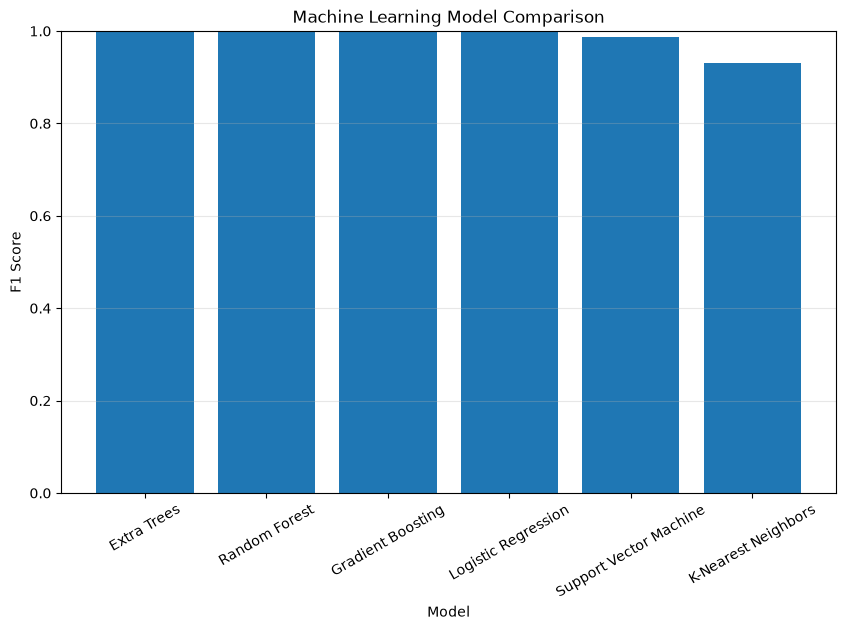

In [32]:
# ============================================================
# 14. VISUALIZE MODEL PERFORMANCE
# ============================================================

plt.figure(

    figsize=(10, 6)

)


plt.bar(

    results_df["Model"],

    results_df["F1 Score"]

)


plt.title(

    "Machine Learning Model Comparison"

)


plt.xlabel(

    "Model"

)


plt.ylabel(

    "F1 Score"

)


plt.xticks(

    rotation=30

)


plt.ylim(

    0,

    1

)


plt.grid(

    axis="y",

    alpha=0.3

)


plt.show()

In [33]:
# ============================================================
# 15. FIND BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]


best_model = trained_models[

    best_model_name

]


print("\n")

print("=" * 60)

print("BEST MODEL")

print("=" * 60)


print(

    f"Best Model: {best_model_name}"

)


print(

    f"Best F1 Score: "

    f"{results_df.iloc[0]['F1 Score']:.4f}"

)



BEST MODEL
Best Model: Extra Trees
Best F1 Score: 1.0000


In [34]:
# ============================================================
# 16. BEST MODEL DETAILED EVALUATION
# ============================================================

y_pred_best = best_model.predict(

    X_test

)


print("\nCLASSIFICATION REPORT")

print(

    classification_report(

        y_test,

        y_pred_best

    )

)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       244
           1       1.00      1.00      1.00        99
           2       1.00      1.00      1.00        98

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441



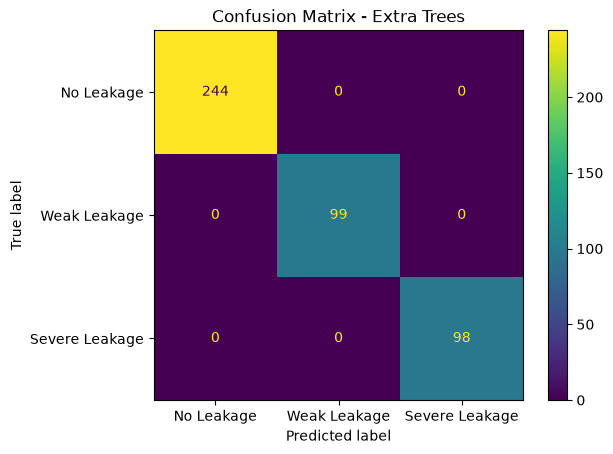

In [35]:
# ============================================================
# 17. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    y_pred_best

)


display = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[

        "No Leakage",

        "Weak Leakage",

        "Severe Leakage"

    ]

)


display.plot()


plt.title(

    f"Confusion Matrix - {best_model_name}"

)


plt.show()

In [36]:
# ============================================================
# 18. CROSS VALIDATION
# ============================================================

cv_results = []


for name, model in models.items():

    print(f"\nCross-validating {name}...")


    scores = cross_val_score(

        model,

        X,

        y,

        cv=5,

        scoring="f1_weighted"

    )


    cv_results.append({

        "Model": name,

        "Mean CV F1": scores.mean(),

        "Standard Deviation": scores.std()

    })


cv_df = pd.DataFrame(

    cv_results

)


cv_df = cv_df.sort_values(

    by="Mean CV F1",

    ascending=False

)


print("\n")

print("=" * 70)

print("CROSS VALIDATION RESULTS")

print("=" * 70)


print(

    cv_df.round(4)

)


Cross-validating Logistic Regression...

Cross-validating K-Nearest Neighbors...

Cross-validating Support Vector Machine...

Cross-validating Random Forest...

Cross-validating Extra Trees...

Cross-validating Gradient Boosting...


CROSS VALIDATION RESULTS
                    Model  Mean CV F1  Standard Deviation
0     Logistic Regression      0.9444              0.0510
3           Random Forest      0.9184              0.0997
5       Gradient Boosting      0.9106              0.1076
4             Extra Trees      0.8375              0.1382
2  Support Vector Machine      0.8319              0.1975
1     K-Nearest Neighbors      0.7048              0.1557



TEST SET RESULTS
                    Model  Accuracy  Precision  Recall  F1 Score
4             Extra Trees    1.0000     1.0000  1.0000    1.0000
3           Random Forest    1.0000     1.0000  1.0000    1.0000
5       Gradient Boosting    0.9977     0.9978  0.9977    0.9977
0     Logistic Regression    0.9977     0.9978  0.9977    0.9977
2  Support Vector Machine    0.9864     0.9865  0.9864    0.9864
1     K-Nearest Neighbors    0.9297     0.9297  0.9297    0.9297

Cross-validating Logistic Regression...

Cross-validating K-Nearest Neighbors...

Cross-validating Support Vector Machine...

Cross-validating Random Forest...

Cross-validating Extra Trees...

Cross-validating Gradient Boosting...

FINAL MODEL COMPARISON
                    Model  Accuracy  Precision  Recall  F1 Score  Mean CV F1  \
3     Logistic Regression    0.9977     0.9978  0.9977    0.9977      0.9444   
1           Random Forest    1.0000     1.0000  1.0000    1.0000      0.9184   
2       Gradient Boosting    0

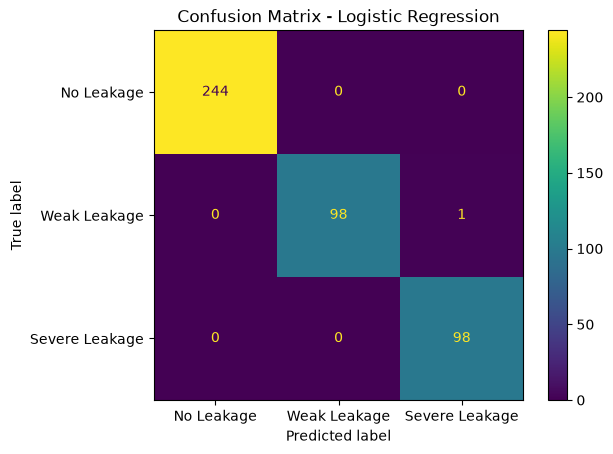


RETRAINING BEST MODEL
Logistic Regression retrained on complete dataset.
Model saved successfully as: best_hydraulic_failure_model.pkl


In [37]:
# ============================================================
# 15. DETERMINE BEST MODEL USING TEST PERFORMANCE + CV
# ============================================================

# ------------------------------------------------------------
# Step 1: Get Test Set Results
# ------------------------------------------------------------

test_results_df = results_df.copy()

print("\n" + "=" * 70)
print("TEST SET RESULTS")
print("=" * 70)

print(test_results_df.round(4))


# ------------------------------------------------------------
# Step 2: Cross Validation for Every Model
# ------------------------------------------------------------

cv_results = []

for name, model in models.items():

    print(f"\nCross-validating {name}...")

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="f1_weighted"
    )

    cv_results.append({

        "Model": name,

        "Mean CV F1": scores.mean(),

        "CV Std": scores.std(),

        "CV Min": scores.min(),

        "CV Max": scores.max()

    })


# Convert to DataFrame

cv_df = pd.DataFrame(cv_results)


# Sort by CV F1

cv_df = cv_df.sort_values(
    by="Mean CV F1",
    ascending=False
)


# ------------------------------------------------------------
# Step 3: Combine Test Results + CV Results
# ------------------------------------------------------------

comparison_df = pd.merge(

    test_results_df,

    cv_df,

    on="Model"

)


# Sort primarily by CV F1

comparison_df = comparison_df.sort_values(

    by="Mean CV F1",

    ascending=False

)


print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

print(

    comparison_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "Mean CV F1",
            "CV Std"
        ]
    ].round(4)

)


# ============================================================
# 16. DETERMINE BEST MODEL
# ============================================================

# Best model = highest mean 5-fold CV F1

best_model_name = comparison_df.iloc[0]["Model"]


# Retrieve the corresponding trained model

best_model = trained_models[best_model_name]


print("\n" + "=" * 70)
print("FINAL BEST MODEL")
print("=" * 70)

print(f"Best Model: {best_model_name}")

print(
    f"Test F1 Score: "
    f"{comparison_df.iloc[0]['F1 Score']:.4f}"
)

print(
    f"Mean CV F1 Score: "
    f"{comparison_df.iloc[0]['Mean CV F1']:.4f}"
)

print(
    f"CV Standard Deviation: "
    f"{comparison_df.iloc[0]['CV Std']:.4f}"
)


# ============================================================
# 17. CHECK TEST PERFORMANCE OF FINAL MODEL
# ============================================================

y_pred_best = best_model.predict(X_test)


print("\n" + "=" * 70)
print("FINAL MODEL CLASSIFICATION REPORT")
print("=" * 70)

print(

    classification_report(

        y_test,

        y_pred_best

    )

)


# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    y_pred_best

)


display = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[

        "No Leakage",

        "Weak Leakage",

        "Severe Leakage"

    ]

)


display.plot()

plt.title(

    f"Confusion Matrix - {best_model_name}"

)

plt.show()


# ============================================================
# 19. RETRAIN BEST MODEL ON COMPLETE DATASET
# ============================================================

print("\n" + "=" * 70)
print("RETRAINING BEST MODEL")
print("=" * 70)


best_model.fit(

    X,

    y

)


print(

    f"{best_model_name} retrained on complete dataset."

)


# ============================================================
# 20. SAVE FINAL MODEL
# ============================================================

model_filename = "best_hydraulic_failure_model.pkl"


joblib.dump(

    best_model,

    model_filename

)


print(

    f"Model saved successfully as: {model_filename}"

)

In [38]:
model_data = {
    "model": best_model,
    "feature_names": X.columns.tolist()
}

joblib.dump(
    model_data,
    "best_hydraulic_failure_model.pkl"
)

print("Model and feature names saved successfully.")

Model and feature names saved successfully.
